In [2]:
#This file studies the relationship between responsa length and time and geography, producing the figures and Tables in the paper.

In [3]:
!pip install pwlf
!pip install python-docx # Install the python-docx package. Important: It's 'python-docx', not just 'docx'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import sklearn as sk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm




from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [5]:
df=pd.read_csv('/content/gdrive/MyDrive/Responsa/bi_plus_geonim.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134343 entries, 0 to 134342
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Unnamed: 0              130926 non-null  float64
 1   author_name             134343 non-null  object 
 2   book_name               134342 non-null  object 
 3   unit                    134222 non-null  object 
 4   word_length             132477 non-null  float64
 5   birth_year              134343 non-null  float64
 6   death_year              110211 non-null  float64
 7   city                    111060 non-null  object 
 8   country                 134343 non-null  object 
 9   other_cities            3934 non-null    object 
 10  approx_birth            17813 non-null   float64
 11  approx_death            6815 non-null    float64
 12  approx_location         3518 non-null    float64
 13  mapped_id               114465 non-null  float64
 14  author_name_stats_fi

/tmp/ipykernel_288/460552749.py:1: DtypeWarning: Columns (7,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/gdrive/MyDrive/Responsa/bi_plus_geonim.csv')


In [6]:
df['region'].unique()

array(['North Africa', 'Iberia', 'Central and Western Europe',
       'Italy and the Balkans', 'West Asia (ex Israel)',
       'Israel/Palestine', 'Eastern Europe', 'North America/Australia'],
      dtype=object)

In [7]:
# Winsorize word_length at the 99th percentile
p998 = df['word_length'].quantile(0.998)
#df['word_length'] = df['word_length'].clip(upper=p998)


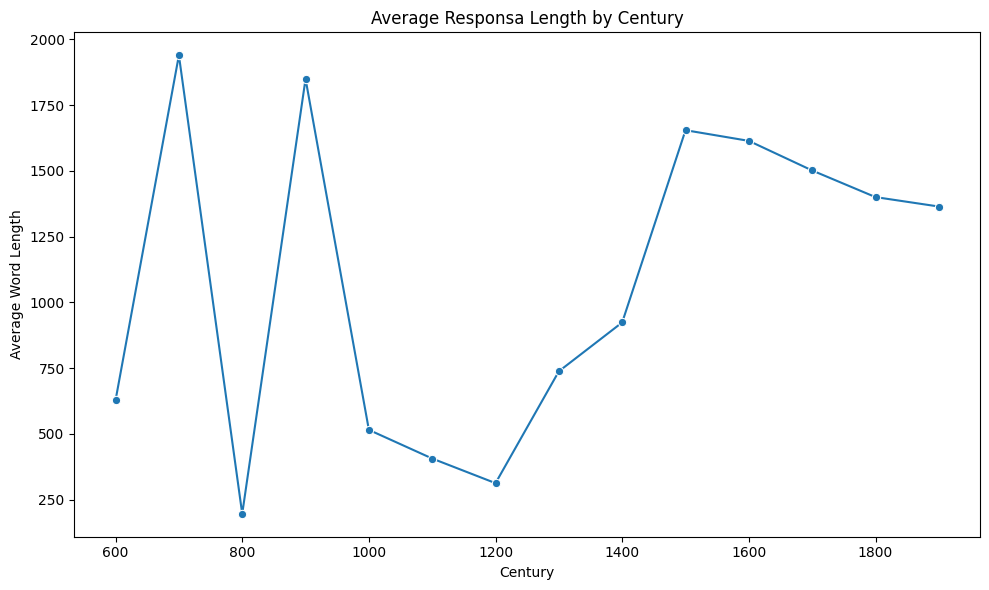

In [8]:

# ------------------------------------
# Step 3: Average word length by century
# ------------------------------------
df['century'] = (df['birth_year'] // 100) * 100
avg_by_century = df.groupby('century')['word_length'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_by_century, x='century', y='word_length', marker='o')
plt.title('Average Responsa Length by Century')
plt.xlabel('Century')
plt.ylabel('Average Word Length')
plt.tight_layout()
plt.show()


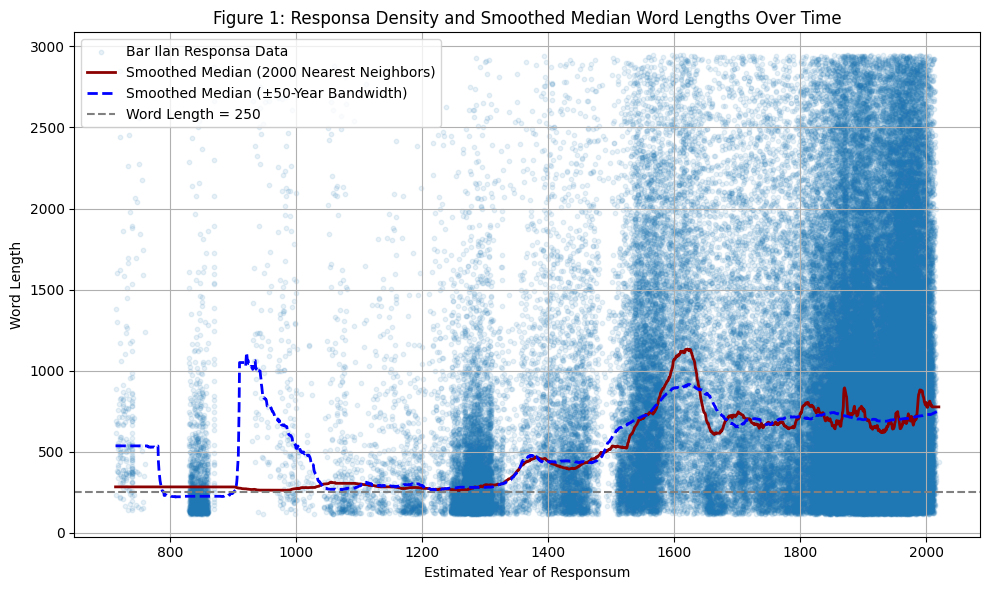

In [9]:
#Getting smoothed median word length over time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Clean and sort the data
df_plot = df[['interpolated_year', 'word_length']].dropna().sort_values('interpolated_year')

# -------------------------------
# Remove outliers (10th to 90th percentile)
lower = df_plot['word_length'].quantile(0.1)
upper = df_plot['word_length'].quantile(0.9)
df_plot = df_plot[(df_plot['word_length'] >= lower) & (df_plot['word_length'] <= upper)]

# Extract arrays
years = df_plot['interpolated_year'].values
lengths = df_plot['word_length'].values

# Grid for smoothing
grid_years = np.linspace(years.min(), years.max(), 2000)

# -------------------------------
# Smoothed median using 2000-nearest-neighbors
k = 2000
median_knn = []
for year in grid_years:
    distances = np.abs(years - year)
    nearest_indices = np.argpartition(distances, k)[:k]
    median_val = np.median(lengths[nearest_indices])
    median_knn.append(median_val)

# -------------------------------
# Smoothed median using fixed 100-year bandwidth
bandwidth = 50
median_fixed = []
for year in grid_years:
    in_band = (years >= year - bandwidth) & (years <= year + bandwidth)
    if np.any(in_band):
        median_val = np.median(lengths[in_band])
    else:
        median_val = np.nan
    median_fixed.append(median_val)

# Define gap period for highlighting
gap_start, gap_end = 1421, 1450

# -------------------------------
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(years, lengths, alpha=0.1, s=10, label='Bar Ilan Responsa Data')
plt.plot(grid_years, median_knn, color='darkred', linewidth=2,
         label=f'Smoothed Median ({k} Nearest Neighbors)')
plt.plot(grid_years, median_fixed, color='blue', linestyle='--', linewidth=2,
         label=f'Smoothed Median (±{bandwidth}-Year Bandwidth)')

plt.axhline(250, color='gray', linestyle='--', linewidth=1.5, label='Word Length = 250')
plt.xlabel("Estimated Year of Responsum")
plt.ylabel("Word Length")
plt.title("Figure 1: Responsa Density and Smoothed Median Word Lengths Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


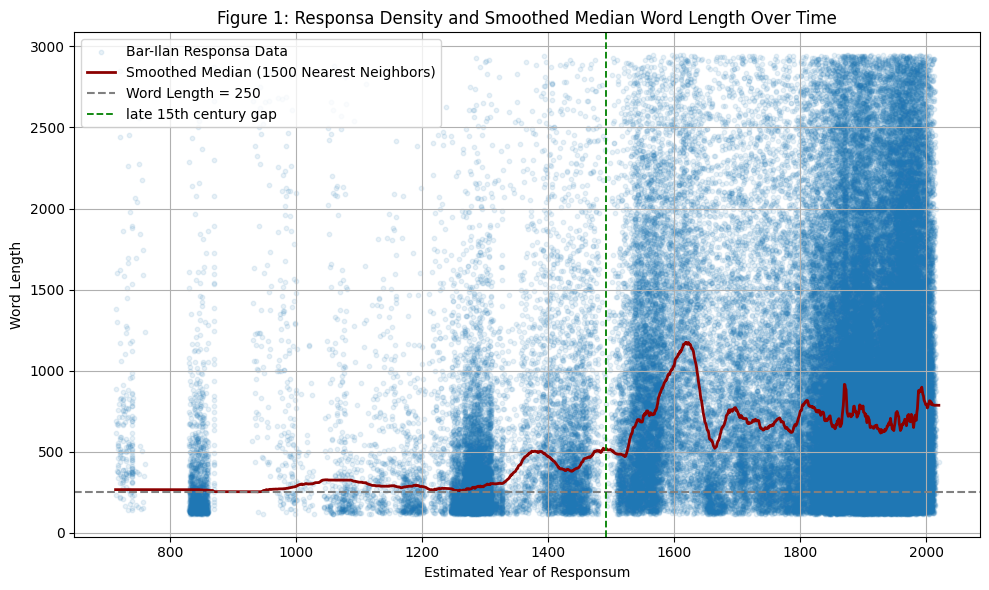

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Clean and sort the data
df_plot = df[['interpolated_year', 'word_length']].dropna().sort_values('interpolated_year')

# -------------------------------
# Remove outliers (1st to 99th percentile)
lower = df_plot['word_length'].quantile(0.1)
upper = df_plot['word_length'].quantile(0.9)
df_plot = df_plot[(df_plot['word_length'] >= lower) & (df_plot['word_length'] <= upper)]

# Extract arrays
years = df_plot['interpolated_year'].values
lengths = df_plot['word_length'].values

# Grid for smoothing
grid_years = np.linspace(years.min(), years.max(), 1500)
median_smoothed = []

# 300 nearest neighbors smoothing
for year in grid_years:
    distances = np.abs(years - year)
    nearest_indices = np.argpartition(distances, 1500)[:1500]
    median_val = np.median(lengths[nearest_indices])
    median_smoothed.append(median_val)

# Define gap period for highlighting
gap_start, gap_end = 1475, 1500



# -------------------------------
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(years, lengths, alpha=0.1, s=10, label='Bar-Ilan Responsa Data')
plt.plot(grid_years, median_smoothed, color='darkred', label='Smoothed Median (1500 Nearest Neighbors)', linewidth=2)
plt.axhline(250, color='gray', linestyle='--', linewidth=1.5, label='Word Length = 250')
plt.axvline(1492, color='green', linestyle='--', linewidth=1.3, label='late 15th century gap')  # Optional: vertical line at 1492
plt.xlabel("Estimated Year of Responsum")
plt.ylabel("Word Length")
plt.title("Figure 1: Responsa Density and Smoothed Median Word Length Over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


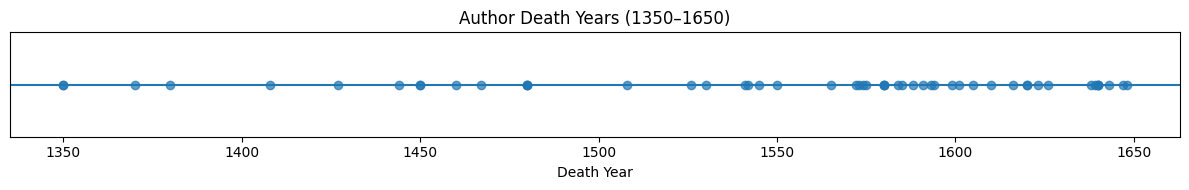

In [11]:
import matplotlib.pyplot as plt
import numpy as np

author_col = 'author_name'

# --- Step 1: One row per author ---
authors = (
    df[[author_col, 'death_year']]
    .dropna()
    .drop_duplicates(subset=author_col)
)

# --- Step 2: Filter to 1350–1650 and sort ---
authors = authors[
    (authors['death_year'] >= 1350) &
    (authors['death_year'] <= 1650)
].sort_values('death_year')

years = authors['death_year'].values

# --- Step 3: Plot (no jitter) ---
plt.figure(figsize=(12,2))

plt.scatter(years, np.zeros_like(years), alpha=0.7)

plt.yticks([])
plt.xlabel('Death Year')
plt.title('Author Death Years (1350–1650)')

plt.axhline(0)



plt.tight_layout()
plt.show()

In [12]:
author_col = 'author_name'

authors = (
    df[[author_col, 'birth_year', 'death_year']]
    .dropna(subset=[author_col, 'death_year'])   # keep rows with author + death year
    .drop_duplicates(subset=author_col)
)

# Filter to 1350–1600 by death year
authors = authors[
    (authors['death_year'] >= 1350) &
    (authors['death_year'] <= 1600)
]

# Sort chronologically
authors = authors.sort_values('death_year').reset_index(drop=True)

authors

,author_name,birth_year,death_year
0,חכמי פרובינציא,1250.0,1350.0
1,ר' משה די ברושליש,1250.0,1350.0
2,ר' משה חלאוה,1290.0,1370.0
3,"ר' ניסים גירונדי )הר""ן(",1320.0,1380.0
4,ר' יצחק בר ששת,1326.0,1408.0
5,ר' יעקב בן משה מולין,1360.0,1427.0
6,ר' שמעון דוראן,1361.0,1444.0
7,ר' צמח ור' שמעון דוראן,1350.0,1450.0
8,ר' יעקב בן יהודה וויל,1390.0,1450.0
9,ר' ישראל בן פתחיה איסרליין,1390.0,1460.0


In [13]:
import pandas as pd
import numpy as np
from math import exp

author_col = 'author_name'

# --- Step 1: one row per author ---
authors = (
    df[[author_col, 'death_year']]
    .dropna(subset=[author_col, 'death_year'])
    .drop_duplicates(subset=author_col)
)

# --- Step 2: keep only desired years ---
authors['death_year'] = authors['death_year'].astype(int)
authors = authors[(authors['death_year'] >= 1250) & (authors['death_year'] <= 1650)]

# --- Step 3: count unique-author deaths per year ---
year_counts = authors['death_year'].value_counts()
year_range = np.arange(1250, 1651)

counts_df = pd.DataFrame({
    'year': year_range,
    'deaths': [year_counts.get(year, 0) for year in year_range]
})

# --- Step 4: estimate average deaths per year ---
lambda_per_year = counts_df['deaths'].mean()
print(f"Estimated average unique-author deaths per year: {lambda_per_year:.3f}")

# --- Step 5: Poisson probability of <=1 deaths in 46 years ---
window_years = 46
lambda_window = lambda_per_year * window_years

prob_0 = exp(-lambda_window)
prob_1 = lambda_window * exp(-lambda_window)
prob_0_or_1 = prob_0 + prob_1

print(f"Estimated probability of <=1 total author deaths in {window_years} years: {prob_0_or_1:.6f}")

Estimated average unique-author deaths per year: 0.155
Estimated probability of <=1 total author deaths in 46 years: 0.006612


In [14]:
(df['author_name'] == "ר' יהודה הלוי מינץ").sum()
(df['author_name'].str.strip() == "ר' יהודה הלוי מינץ").sum()

np.int64(15)

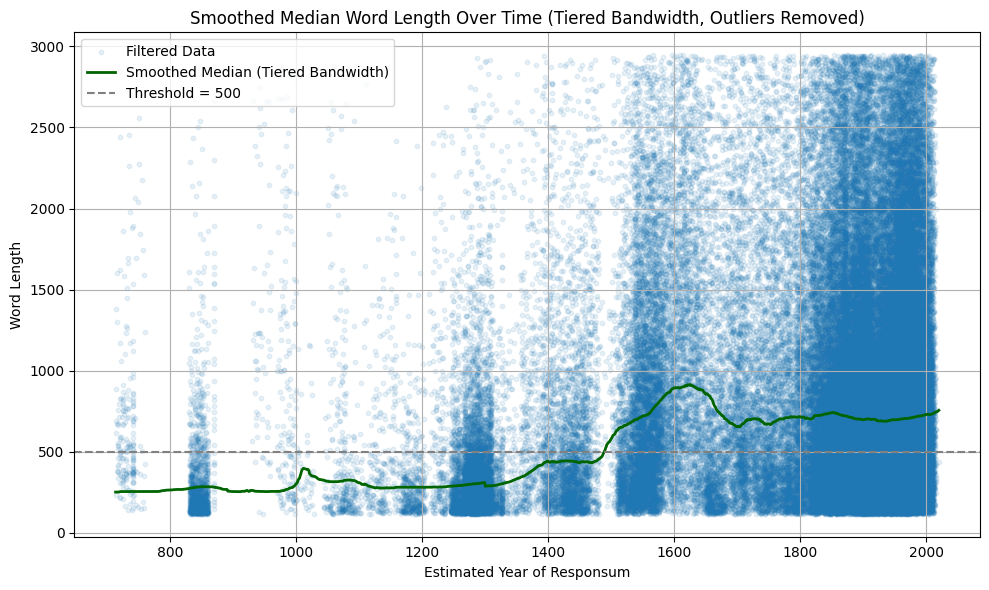

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Prepare the data
df2 = df[['interpolated_year', 'word_length']].dropna()

# Step 2: Remove outliers (1st to 99th percentile)
lower, upper = df2['word_length'].quantile([0.1, 0.90])
df2 = df2[df2['word_length'].between(lower, upper)]

# Step 3: Extract arrays
years = df2['interpolated_year'].values
lengths = df2['word_length'].values

# Step 4: Define evaluation grid
grid_years = np.arange(int(years.min()), int(years.max()) + 1)

# Step 5: Apply tiered bandwidth smoothing
median_smoothed = []

for y in grid_years:
    if y < 1200:
        bw = 150
    elif y < 1300:
        bw = 125
    elif y < 1400:
        bw = 75
    else:
        bw = 50
    mask = (years >= y - bw) & (years <= y + bw)
    median = np.median(lengths[mask]) if mask.sum() > 0 else np.nan
    median_smoothed.append(median)

# Step 6: Plot
plt.figure(figsize=(10, 6))
plt.scatter(years, lengths, alpha=0.1, s=10, label='Filtered Data')
plt.plot(grid_years, median_smoothed, color='darkgreen', linewidth=2,
         label='Smoothed Median (Tiered Bandwidth)')
plt.axhline(500, color='gray', linestyle='--', linewidth=1.5, label='Threshold = 500')
plt.xlabel("Estimated Year of Responsum")
plt.ylabel("Word Length")
plt.title("Smoothed Median Word Length Over Time (Tiered Bandwidth, Outliers Removed)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
#Finding the longest gap between birth years between the year 1000 and the present.

# Step 1: Filter birth_years > 1000, drop NaNs, and sort
birth_years = df['birth_year'].dropna()
birth_years = birth_years[birth_years > 1200].unique()
birth_years.sort()

# Step 2: Compute the gaps
gaps = np.diff(birth_years)

# Step 3: Find the longest gap and corresponding years
max_gap_index = np.argmax(gaps)
max_gap = gaps[max_gap_index]
start_year = birth_years[max_gap_index]
end_year = birth_years[max_gap_index + 1]

# Output the result
print(f"The longest gap after year 1000 is {int(max_gap)} years, between {int(start_year)} and {int(end_year)}.")


The longest gap after year 1000 is 30 years, between 1290 and 1320.


In [17]:
#Estimating the probability of having an author born in a given year between 1000 and 1400. and then estimating the probability of a 30 year period with no authors.
import pandas as pd
import numpy as np

# Get clean list of birth years between 1000 and 1500
birth_years = df['birth_year'].dropna().astype(int)
birth_years = birth_years[(birth_years >= 1250) & (birth_years <= 1650)]

# Count how many unique years had at least one birth
observed_years = set(birth_years)
year_range = np.arange(1250, 1651)

# Create a DataFrame for years and presence
presence_df = pd.DataFrame({
    'year': year_range,
    'has_author': [1 if year in observed_years else 0 for year in year_range]
})

# Estimate probability: mean of binary indicator
probability = presence_df['has_author'].mean()

print(f"Estimated probability of at least one author born in a given year between 1250 and 1650: {probability:.3f}")


# Estimate p from earlier step
prob_year = presence_df['has_author'].mean()
prob_no_author_year = 1 - prob_year

# Probability of no authors for 30 consecutive years
prob_no_authors_30_years = prob_no_author_year ** 28

print(f"Estimated probability of NO authors being born over 28 consecutive years: {prob_no_authors_30_years:.5f}")



Estimated probability of at least one author born in a given year between 1250 and 1650: 0.142
Estimated probability of NO authors being born over 28 consecutive years: 0.01366


In [18]:
#Getting the names of geonic authors

# Filter authors born during the Geonic era (roughly 589–1000)
geonic_authors = df[(df['birth_year'] >= 589) & (df['birth_year'] < 1000)]

# Get unique names
geonic_author_names = geonic_authors['author_name'].dropna().unique()

# Display sorted list
geonic_author_names_sorted = sorted(geonic_author_names)
print(geonic_author_names_sorted)


['החילוקים', 'הלכות קצובות', "ר' אחאי משבחא", "ר' גרשום מאור הגולה", "ר' האי גאון", "ר' יהודאי גאון", "ר' עמרם גאון", "ר' שמעון קיירא", 'תשובות הגאונים']


<Figure size 1400x700 with 0 Axes>

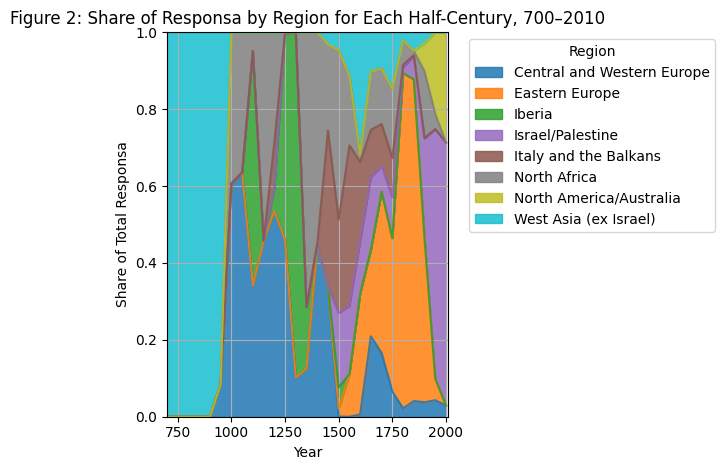

In [19]:
#Making a figure to track how the number of responsa varies over time and place

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Filter and clean the data
df_region = df[['interpolated_year', 'region']].dropna()
df_region = df_region[(df_region['interpolated_year'] >= 700) & (df_region['interpolated_year'] <= 2020)]

# Step 2: Bin into 50-year periods
df_region['half_century'] = ((df_region['interpolated_year'] // 50) * 50).astype(int)
df_region['century'] = ((df_region['interpolated_year'] // 100) * 100).astype(int)

# Step 3: Count responsa per region per period
counts = df_region.groupby(['half_century', 'region']).size().unstack(fill_value=0)

# Step 4: Convert to share of total responsa in each period
region_shares = counts.div(counts.sum(axis=1), axis=0)

# Step 5: Plot as stacked area chart of shares
plt.figure(figsize=(14, 7))
region_shares.plot.area(colormap='tab10', alpha=0.85)

plt.title("Figure 2: Share of Responsa by Region for Each Half-Century, 700–2010")
plt.xlabel("Year")
plt.ylabel("Share of Total Responsa")
plt.ylim(0, 1)
plt.xlim(700, 2010)
plt.grid(True)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [20]:
import pandas as pd
import statsmodels.formula.api as smf
from docx import Document

# Step 1: Prepare your data
df_reg = df[['word_length', 'region', 'interpolated_year', 'author_name']].dropna()
df_reg['half_century'] = (df_reg['interpolated_year'] // 50) * 50

df_reg['region'] = pd.Categorical(df_reg['region'],
                                  categories=sorted(df_reg['region'].unique(), key=lambda x: x != 'North Africa'),
                                  ordered=True)



# Step 2: Run regression (uses default omitted category = first alphabetically)
model = smf.ols(
    formula='word_length ~ C(region) + C(half_century)',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['author_name']}
)

# Step 3: Extract coefficients for region dummies
params = model.params
bse = model.bse
pvals = model.pvalues

region_rows = [i for i in params.index if 'C(region)' in i]

# Step 4: Format output with stars
def star(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    else:
        return ''

rows = []
for row in region_rows:
    region_name = row.replace('C(region)[T.', '').replace('C(region)[', '').replace(']', '')
    coef = params[row]
    se = bse[row]
    pval = pvals[row]
    stars = star(pval)
    formatted = f"{coef:.2f}{stars}\n({se:.2f})"
    rows.append({'Region': region_name, 'Formatted': formatted})

table_df = pd.DataFrame(rows)

# Step 5: Display results in Python
print("\nRegression Results: Region Effects on Word Length (Clustered by Author)")
print(table_df.set_index('Region'))

# Step 6: Export to Word
doc = Document()
doc.add_heading('Table 2: Regression Results: Region Effects on Word Length (Clustered by Author)', level=1)

table = doc.add_table(rows=1, cols=2)
table.style = 'Table Grid'
hdr_cells = table.rows[0].cells
hdr_cells[0].text = 'Region'
hdr_cells[1].text = 'Estimate (SE)'

for _, row in table_df.iterrows():
    cells = table.add_row().cells
    cells[0].text = row['Region']
    cells[1].text = row['Formatted']

doc.add_paragraph('\nNote: * p < 0.10, ** p < 0.05, *** p < 0.01')

# Save the document
output_path = "/content/gdrive/MyDrive/Responsa/region_regression_results_with_stars.docx"
doc.save(output_path)



Regression Results: Region Effects on Word Length (Clustered by Author)
                                     Formatted
Region                                        
Iberia                        104.45\n(147.27)
Central and Western Europe    103.35\n(155.84)
Italy and the Balkans       747.59**\n(299.68)
West Asia (ex Israel)         382.29\n(299.90)
Israel/Palestine            511.98**\n(219.88)
Eastern Europe               357.40*\n(184.99)
North America/Australia       215.40\n(224.17)


In [21]:
import pandas as pd
import statsmodels.formula.api as smf
from docx import Document

# Step 1: Prepare your data
df_reg = df[['word_length', 'region', 'interpolated_year', 'author_name']].dropna()
df_reg = df_reg[(df_reg['interpolated_year'] >= 1000) & (df_reg['interpolated_year'] <= 1350)]
df_reg['half_century'] = (df_reg['interpolated_year'] // 50) * 50

df_reg['region'] = pd.Categorical(df_reg['region'],
                                  categories=sorted(df_reg['region'].unique(), key=lambda x: x != 'North Africa'),
                                  ordered=True)



# Step 2: Run regression (uses default omitted category = first alphabetically)

import statsmodels.api as sm

model = smf.quantreg(
    formula='word_length ~ C(region) + C(half_century)',
    data=df_reg
).fit(q=0.5)

# Step 3: Extract coefficients for region dummies
params = model.params
bse = model.bse
pvals = model.pvalues

region_rows = [i for i in params.index if 'C(region)' in i]

# Step 4: Format output with stars
def star(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    else:
        return ''

rows = []
for row in region_rows:
    region_name = row.replace('C(region)[T.', '').replace('C(region)[', '').replace(']', '')
    coef = params[row]
    se = bse[row]
    pval = pvals[row]
    stars = star(pval)
    formatted = f"{coef:.2f}{stars}\n({se:.2f})"
    rows.append({'Region': region_name, 'Formatted': formatted})

table_df = pd.DataFrame(rows)

# Step 5: Display results in Python
print("\nRegression Results: Region Effects on Word Length (Clustered by Author)")
print(table_df.set_index('Region'))

# Step 6: Export to Word
doc = Document()
doc.add_heading('Table 2: Regression Results: Region Effects on Word Length (Clustered by Author)', level=1)

table = doc.add_table(rows=1, cols=2)
table.style = 'Table Grid'
hdr_cells = table.rows[0].cells
hdr_cells[0].text = 'Region'
hdr_cells[1].text = 'Estimate (SE)'

for _, row in table_df.iterrows():
    cells = table.add_row().cells
    cells[0].text = row['Region']
    cells[1].text = row['Formatted']

doc.add_paragraph('\nNote: * p < 0.10, ** p < 0.05, *** p < 0.01')

# Save the document
output_path = "/content/gdrive/MyDrive/Responsa/region_regression_results_with_stars.docx"
doc.save(output_path)



Regression Results: Region Effects on Word Length (Clustered by Author)
                                     Formatted
Region                                        
Iberia                          -2.00\n(10.61)
Central and Western Europe      -15.00\n(9.52)
Italy and the Balkans       273.75***\n(22.45)


In [22]:
df_reg['region'].unique()

['North Africa', 'Iberia', 'Central and Western Europe', 'Italy and the Balkans']
Categories (4, object): ['North Africa' < 'Iberia' < 'Central and Western Europe' <
                         'Italy and the Balkans']

In [28]:
import pandas as pd
import statsmodels.formula.api as smf

# --- 1. Ensure required columns exist ---
reg_df = df.dropna(subset=["year", "word_length", "country", "author_name"]).copy()

# --- 2. Create 25-year bins ---
reg_df["quarter_century"] = (reg_df["year"] // 25) * 25
reg_df["quarter_century"] = reg_df["quarter_century"].astype(int).astype(str)

# --- 3. Region classification ---
four_part_regions = {
    "Ashkenaz": [
        "Russia", "Poland", "Ukraine", "Lithuania", "Latvia", "Estonia",
        "Belarus", "Hungary", "Czech Republic", "Slovakia", "Romania", "Bulgaria",
        "France", "Germany", "Netherlands", "Belgium", "Switzerland",
        "Austria", "United Kingdom", "England", "Ireland",
        "United States", "USA", "Canada", "Mexico", "Australia"
    ],
    "Italian": [
        "Italy", "Yugoslavia", "Bosnia",
        "Serbia", "Croatia", "Bosnia-Herzegovina"
    ],
    "Sepharad": [
        "Spain", "Portugal",
        "Morocco", "Algeria", "Tunisia", "Libya", "Egypt",
        "Israel", "Palestine", "Ottoman Palestine", "Mandatory Palestine",
        "Eretz Israel", "ישראל",
        "Turkey", "Syria", "Greece",
    ],
    "West Asia": [
        "Saudi Arabia", "Yemen", "Oman", "United Arab Emirates", "Arabia", "Hejaz",
        "Iraq", "Iran", "Mesopotamia", "Persia",
        "Lebanon", "Jordan", "Qatar", "Bahrain", "Kuwait",
        "Georgia", "Armenia", "Azerbaijan"
    ]
}

country_to_region = {
    country: region
    for region, countries in four_part_regions.items()
    for country in countries
}

reg_df["region"] = reg_df["country"].map(country_to_region)
reg_df = reg_df.dropna(subset=["region"])

# --- 4. Regression with 25-year dummies ---
model = smf.ols(
    "word_length ~ C(quarter_century) + C(region)",
    data=reg_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["author_name"]}
)

# --- 5. Show ONLY regional coefficients ---
coefs = model.summary2().tables[1]
region_coefs = coefs[coefs.index.str.contains("C\\(region\\)")]

print(region_coefs)

                             Coef.    Std.Err.         z     P>|z|  \
C(region)[T.Italian]     39.887087  297.254113  0.134185  0.893256   
C(region)[T.Sepharad]   150.401928  138.245024  1.087937  0.276623   
C(region)[T.West Asia] -735.095566  276.590948 -2.657699  0.007868   

                             [0.025      0.975]  
C(region)[T.Italian]    -542.720270  622.494444  
C(region)[T.Sepharad]   -120.553340  421.357197  
C(region)[T.West Asia] -1277.203863 -192.987270  


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 53, but rank is 49
  warnings.warn('covariance of constraints does not have full '
